In [55]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("husl")

In [56]:
iris = fetch_ucirepo(id=53)   
X = iris.data.features 
y = iris.data.targets 

### Shape

In [57]:
records, features = X.shape
f"IRIS: number of records: {records}, number of features: {features}"

'IRIS: number of records: 150, number of features: 4'

### Missing values

In [58]:
nulls = pd.DataFrame(X).isnull().sum()
nulls

sepal length    0
sepal width     0
petal length    0
petal width     0
dtype: int64

___

- sepal length – długość działki kielicha
- sepal width – szerokość działki kielicha
- petal length – długość płatka
- petal width – szerokość płatka

In [59]:
X

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [60]:
y

,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


___

### class distribution

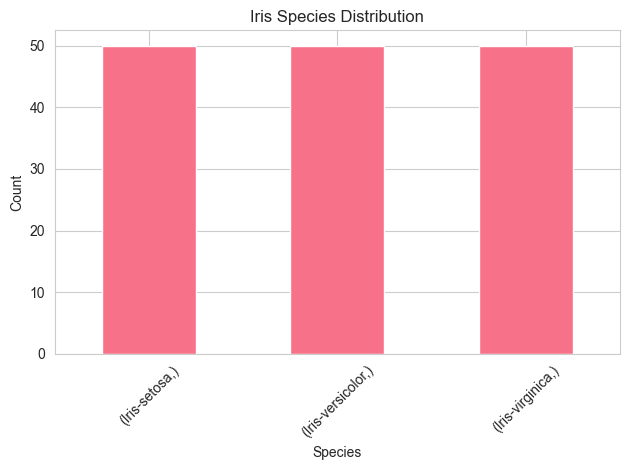

In [61]:
ax = y.value_counts().plot(kind='bar')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.set_title('Iris Species Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

___

### Feature distributions by class

In [66]:
df = X.copy()
df['species'] = y.values.ravel()
features = X.columns

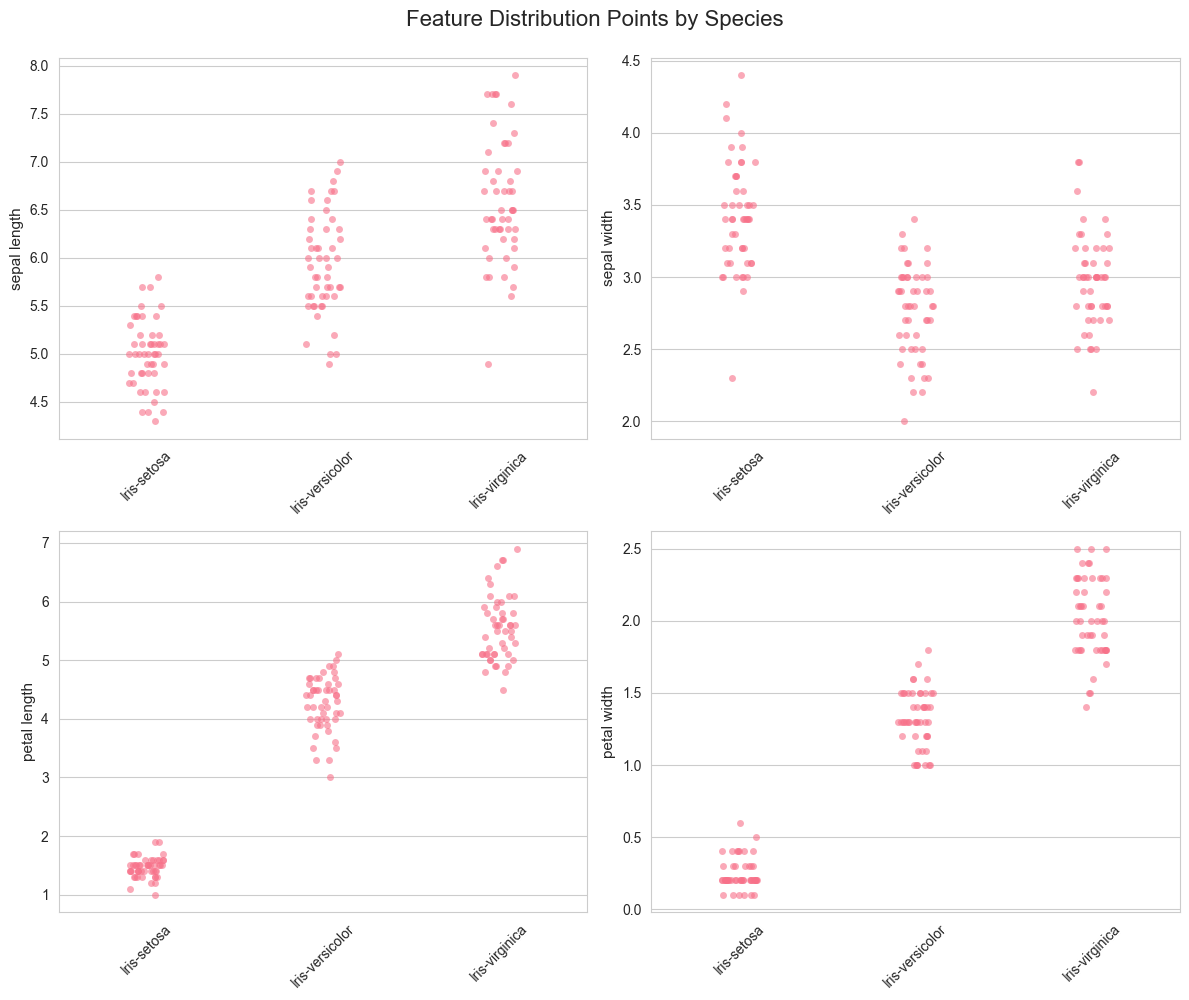

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Feature Distribution Points by Species', fontsize=16, y=0.995)

for idx, feature in enumerate(features):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    sns.stripplot(data=df, x='species', y=feature, ax=ax, alpha=0.6, size=5)
    ax.set_xlabel('')
    ax.set_ylabel(feature, fontsize=11)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

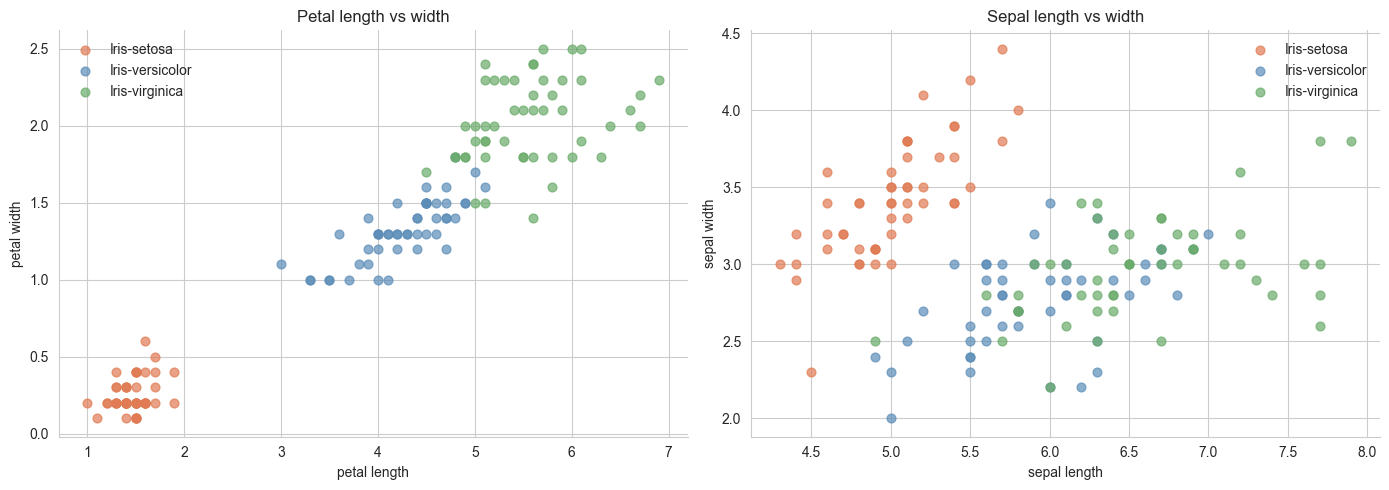

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'Iris-setosa': '#e07b54', 'Iris-versicolor': '#5b8db8', 'Iris-virginica': '#6aab6a'}

for species, group in df.groupby('species'):
    axes[0].scatter(group['petal length'], group['petal width'],
                    label=species, alpha=0.7, s=40, color=palette[species])
axes[0].set_xlabel('petal length')
axes[0].set_ylabel('petal width')
axes[0].set_title('Petal length vs width')
axes[0].legend(frameon=False)

for species, group in df.groupby('species'):
    axes[1].scatter(group['sepal length'], group['sepal width'],
                    label=species, alpha=0.7, s=40, color=palette[species])
axes[1].set_xlabel('sepal length')
axes[1].set_ylabel('sepal width')
axes[1].set_title('Sepal length vs width')
axes[1].legend(frameon=False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

___

### PCA

In [76]:
from sklearn.decomposition import PCA

In [90]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

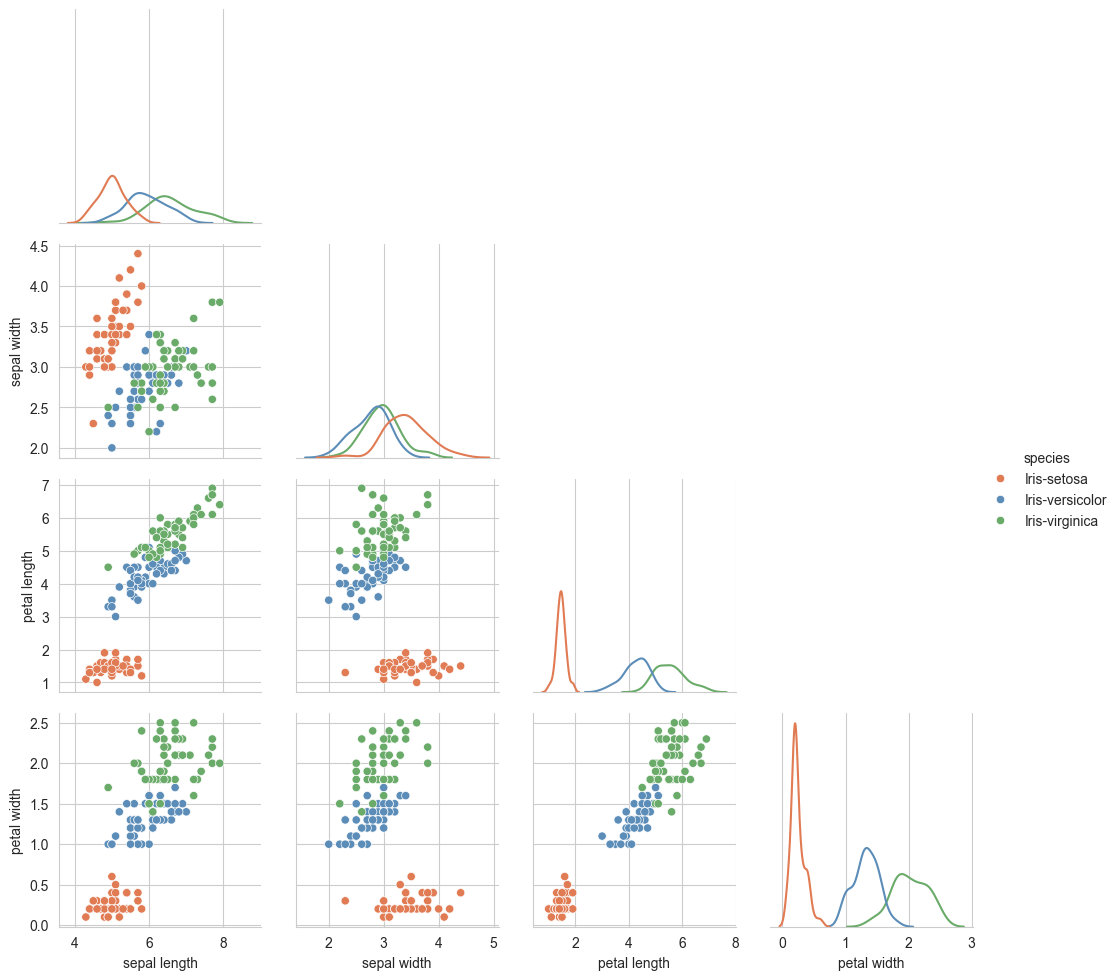

In [ ]:
g = sns.PairGrid(df, hue='species', palette=palette, corner=True)
g.map_lower(sns.scatterplot)
g.map_diag(sns.kdeplot)
g.add_legend()
plt.show()

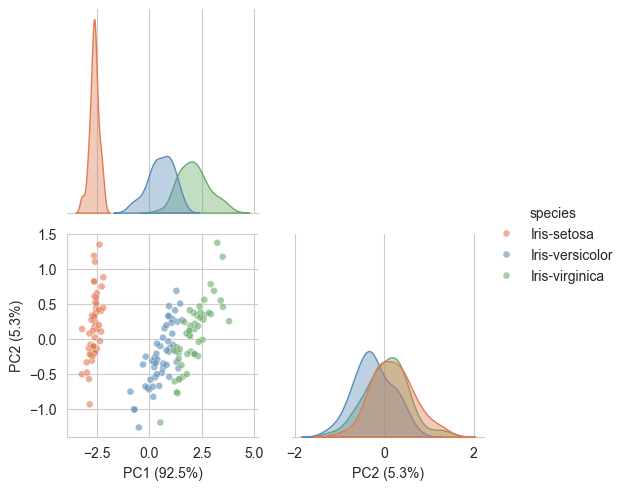

In [92]:
var = pca.explained_variance_ratio_ * 100
df_pca = pd.DataFrame(X_pca, columns=[f'PC1 ({var[0]:.1f}%)', f'PC2 ({var[1]:.1f}%)'])
df_pca['species'] = df['species'].values

g = sns.PairGrid(df_pca, hue='species', palette=palette, corner=True)
g.map_lower(sns.scatterplot, alpha=0.6, s=25)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4)
g.add_legend(frameon=False)
plt.show()